<a href="https://colab.research.google.com/github/Mastermind0309/NTUH_HCC/blob/main/ForestPlot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/palliative_combo_figure.jpg'

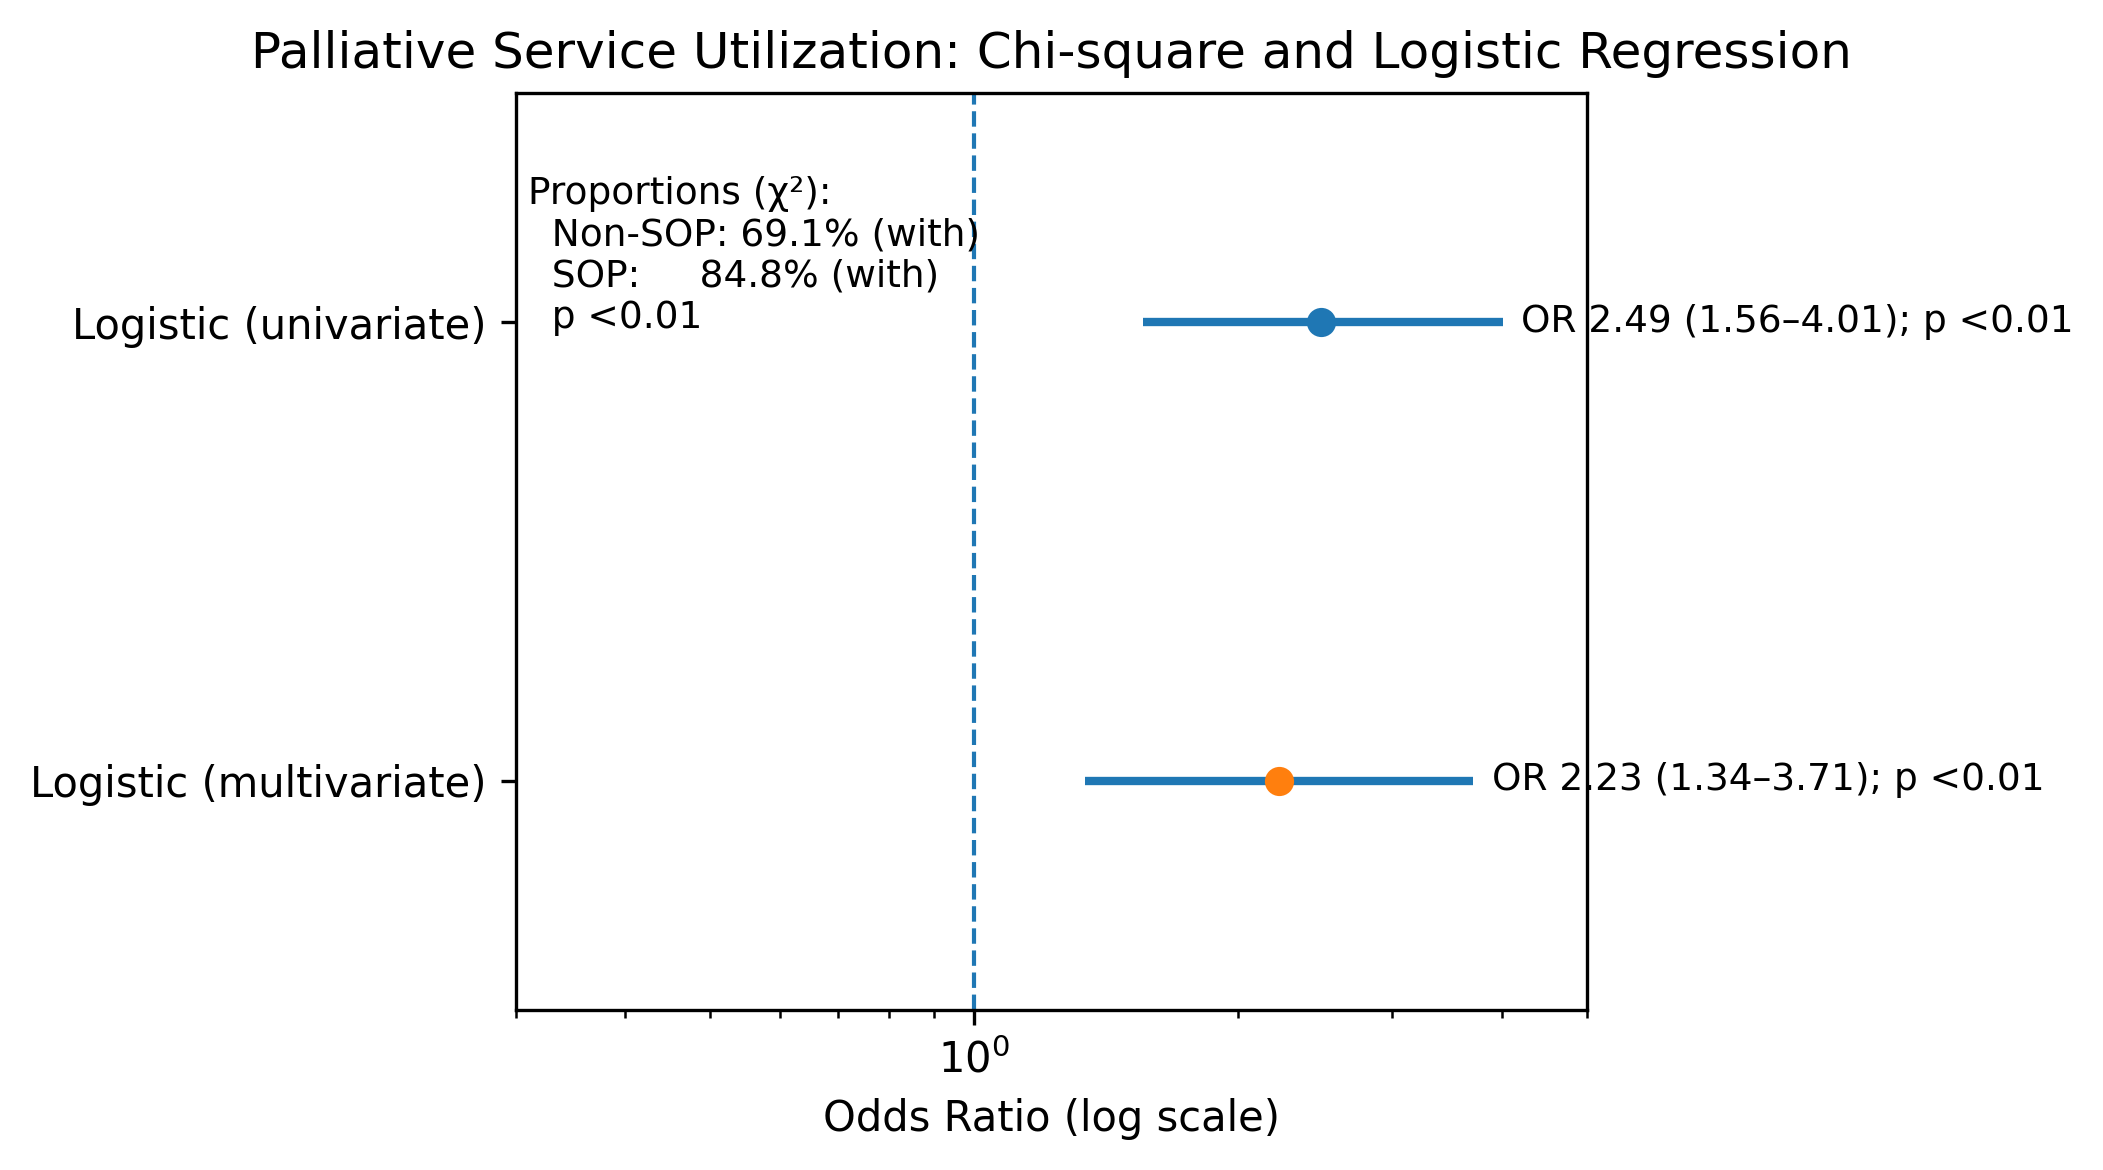

In [ ]:
import matplotlib.pyplot as plt

# ---- Updated numbers from your tables ----
# Table 2 (counts)
n_non, with_non = 236, 163
n_sop, with_sop = 204, 173

# Within-group proportions (% with palliative service)
prop_non_with = with_non / n_non * 100   # ≈ 69.1%
prop_sop_with = with_sop / n_sop * 100   # ≈ 84.8%
p_chi = "<0.01"  # chi-square p-value

# Table 3 (logistic regression ORs)
points = [
    {"label": "Logistic (univariate)", "OR": 2.49, "low": 1.56, "high": 4.01, "p": "<0.01"},
    {"label": "Logistic (multivariate)", "OR": 2.23, "low": 1.34, "high": 3.71, "p": "<0.01"},
]

# ---- Figure ----
plt.figure(figsize=(7, 4), dpi=300)
y_positions = [1, 0]

# CIs + points
for y, item in zip(y_positions, points):
    plt.hlines(y, xmin=item["low"], xmax=item["high"], linewidth=2)
    plt.plot(item["OR"], y, 'o', markersize=6)

# Null line at OR=1
plt.axvline(1.0, linestyle='--', linewidth=1)

plt.xscale('log')
plt.xlim(0.3, 5.0)
plt.yticks(y_positions, [i["label"] for i in points])
plt.ylim(-0.5, 1.5)
plt.xlabel("Odds Ratio (log scale)")

# Right-side labels
for y, item in zip(y_positions, points):
    plt.text(item["high"]*1.05, y,
             f'OR {item["OR"]:.2f} ({item["low"]:.2f}–{item["high"]:.2f}); p {item["p"]}',
             va='center', ha='left', fontsize=9)

# Left block: proportions and chi-square
left_text = (
    "Proportions (χ²):\n"
    f"  Non-SOP: {prop_non_with:.1f}% (with)\n"
    f"  SOP:     {prop_sop_with:.1f}% (with)\n"
    f"  p {p_chi}"
)
plt.text(0.31, 1.32, left_text, ha='left', va='top', fontsize=9)

plt.title("Palliative Service Utilization: Chi-square and Logistic Regression")
plt.tight_layout()

# Save 300-DPI JPG
out_path = "/mnt/data/palliative_combo_figure.jpg"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", out_path)
